<a href="https://colab.research.google.com/github/OlhaZahrebelna/A-B-testing/blob/main/AB_testing_ENG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

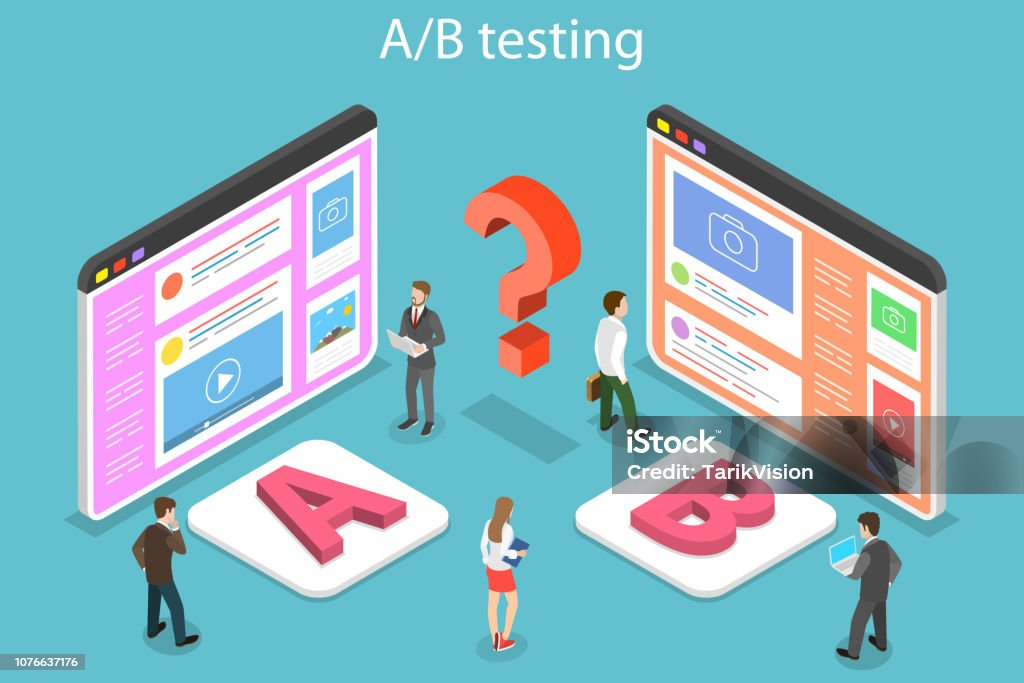

We have data on a marketing campaign where users are divided into a control group (Control) and a test group (Test). We want to determine whether the new approach (Test campaign) has a better impact on conversion and user behavior compared to the old approach (Control campaign).

Below are all the features in the dataset:

Campaign Name: The name of the campaign

Date: Date of the record

Spend: Amount spent on the campaign in dollars

of Impressions: Number of impressions the ad crossed through the campaign

Reach: The number of unique impressions received in the ad

of Website Clicks: Number of website clicks received through the ads

of Searches: Number of users who performed searches on the website

of View Content: Number of users who viewed content and products on the website

of Add to Cart: Number of users who added products to the cart

of Purchase: Number of purchases

# Data Loading and Processing.

### Loading the necessary libraries for analysis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import shapiro

from warnings import simplefilter
simplefilter("ignore")

### Loading the control group data.

In [2]:
control_group = pd.read_csv("control_group.csv", sep=";", parse_dates=["Date"], dayfirst=True)
control_group.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,2019-08-05,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Loading the test group data.

In [3]:
test_group = pd.read_csv("test_group.csv", sep=";", parse_dates=["Date"], dayfirst=True)
test_group.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,2019-08-01,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2019-08-02,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,2019-08-03,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,2019-08-04,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,2019-08-05,2297,114295,95138,5863,2106,858,956,768


### For convenience, we rename the columns. Checking the data format and missing values.

In [4]:
control_group.rename(columns= { "# of Impressions": "Impressions", "# of Website Clicks": "Number of Website Clicks",
                     "# of Searches": "Number of Searches", "# of View Content": "Number of View Content",
                     "# of Add to Cart": "Add to Cart", "# of Purchase": "Number of purchases"}, inplace=True)

In [6]:
test_group.rename(columns= { "# of Impressions": "Impressions", "# of Website Clicks": "Number of Website Clicks",
                     "# of Searches": "Number of Searches", "# of View Content": "Number of View Content",
                     "# of Add to Cart": "Add to Cart", "# of Purchase": "Number of purchases"}, inplace=True)

In [5]:
control_group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Campaign Name             30 non-null     object        
 1   Date                      30 non-null     datetime64[ns]
 2   Spend [USD]               30 non-null     int64         
 3   Impressions               29 non-null     float64       
 4   Reach                     29 non-null     float64       
 5   Number of Website Clicks  29 non-null     float64       
 6   Number of Searches        29 non-null     float64       
 7   Number of View Content    29 non-null     float64       
 8   Add to Cart               29 non-null     float64       
 9   Number of purchases       29 non-null     float64       
dtypes: datetime64[ns](1), float64(7), int64(1), object(1)
memory usage: 2.5+ KB


In [7]:
test_group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Campaign Name             30 non-null     object        
 1   Date                      30 non-null     datetime64[ns]
 2   Spend [USD]               30 non-null     int64         
 3   Impressions               30 non-null     int64         
 4   Reach                     30 non-null     int64         
 5   Number of Website Clicks  30 non-null     int64         
 6   Number of Searches        30 non-null     int64         
 7   Number of View Content    30 non-null     int64         
 8   Add to Cart               30 non-null     int64         
 9   Number of purchases       30 non-null     int64         
dtypes: datetime64[ns](1), int64(8), object(1)
memory usage: 2.5+ KB


The control group is **missing data for the 4th day**. We considered several options to address this issue (filling in the missing values, removing the day from the analysis, using the test group to impute values) and decided that the best approach is **to fill in the missing values with the arithmetic mean**. First, we will select all columns with numerical values, and then we will fill in the missing values with their mean.

In [8]:
numeric_cols = control_group.select_dtypes(include=np.number).columns
control_group[numeric_cols] = control_group[numeric_cols].fillna(control_group[numeric_cols].mean())

In [9]:
control_group.head()

,Campaign Name,Date,Spend [USD],Impressions,Reach,Number of Website Clicks,Number of Searches,Number of View Content,Add to Cart,Number of purchases
0,Control Campaign,2019-08-01,2280,82702.000000,56930.000000,7016.000000,2290.000000,2159.000000,1819.0,618.000000
1,Control Campaign,2019-08-02,1757,121040.000000,102513.000000,8110.000000,2033.000000,1841.000000,1219.0,511.000000
2,Control Campaign,2019-08-03,2343,131711.000000,110862.000000,6508.000000,1737.000000,1549.000000,1134.0,372.000000
3,Control Campaign,2019-08-04,1940,72878.000000,61235.000000,3065.000000,1042.000000,982.000000,1183.0,340.000000
4,Control Campaign,2019-08-05,1835,109559.758621,88844.931034,5320.793103,2221.310345,1943.793103,1300.0,522.793103


In [10]:
display(f"The control group has {control_group.shape[0]} rows and {control_group.shape[1]} columns.")
display(f"The test group has {test_group.shape[0]} rows and {test_group.shape[1]} columns.")

'The control group has 30 rows and 10 columns.'

'The test group has 30 rows and 10 columns.'

### Reviewing the values in the control and test groups before the main analysis.

I suggest reviewing the values in the control and test groups to assess their distribution and potential differences. This will help us better understand the data before conducting further analysis.

In [11]:
control_group.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,30,2019-08-15 12:00:00,2019-08-01 00:00:00,2019-08-08 06:00:00,2019-08-15 12:00:00,2019-08-22 18:00:00,2019-08-30 00:00:00,NaN
Spend [USD],30.0,2288.433333,1757.0,1945.5,2299.5,2532.0,3083.0,367.334451
Impressions,30.0,109559.758621,71274.0,95191.25,112368.0,121259.0,145248.0,21311.695472
Reach,30.0,88844.931034,42859.0,75300.25,91418.0,101958.75,127852.0,21452.627592
Number of Website Clicks,30.0,5320.793103,2277.0,4122.25,5272.396552,6609.5,8137.0,1726.803732
Number of Searches,30.0,2221.310345,1001.0,1629.25,2340.0,2655.0,4891.0,851.025795
Number of View Content,30.0,1943.793103,848.0,1249.0,1979.5,2360.5,4219.0,764.021907
Add to Cart,30.0,1300.0,442.0,942.5,1319.5,1638.0,1913.0,400.371207
Number of purchases,30.0,522.793103,222.0,375.5,506.0,663.25,800.0,181.810508


In [12]:
test_group.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,30,2019-08-15 12:00:00,2019-08-01 00:00:00,2019-08-08 06:00:00,2019-08-15 12:00:00,2019-08-22 18:00:00,2019-08-30 00:00:00,NaN
Spend [USD],30.0,2563.066667,1968.0,2324.5,2584.0,2836.25,3112.0,348.687681
Impressions,30.0,74584.8,22521.0,47541.25,68853.5,99500.0,133771.0,32121.377422
Reach,30.0,53491.566667,10598.0,31516.25,44219.5,78778.75,109834.0,28795.775752
Number of Website Clicks,30.0,6032.333333,3038.0,4407.0,6242.5,7604.75,8264.0,1708.567263
Number of Searches,30.0,2418.966667,1854.0,2043.0,2395.5,2801.25,2978.0,388.742312
Number of View Content,30.0,1858.0,858.0,1320.0,1881.0,2412.0,2801.0,597.654669
Add to Cart,30.0,881.533333,278.0,582.5,974.0,1148.5,1391.0,347.584248
Number of purchases,30.0,521.233333,238.0,298.0,500.0,701.0,890.0,211.047745


Key differences between the groups:

**More money** was spent on the test group compared to the
control group.

However, **the number of impressions, reach, content views,
and add-to-cart actions is significantly lower** in the test group.

Conversely, **the number of website clicks and searches** is higher in the test group.

**The number of purchases** is almost the **same** in both groups.


I suggest merging these two groups into a single table.

In [13]:
concat_table = pd.concat([control_group, test_group])

In the next step, **visualizations** will be presented to **better understand the key insights** from the data analysis. We will use charts to compare metrics between the control and test groups.

In [15]:
concat_table.columns

Index(['Campaign Name', 'Date', 'Spend [USD]', 'Impressions', 'Reach',
       'Number of Website Clicks', 'Number of Searches',
       'Number of View Content', 'Add to Cart', 'Number of purchases'],
      dtype='object')

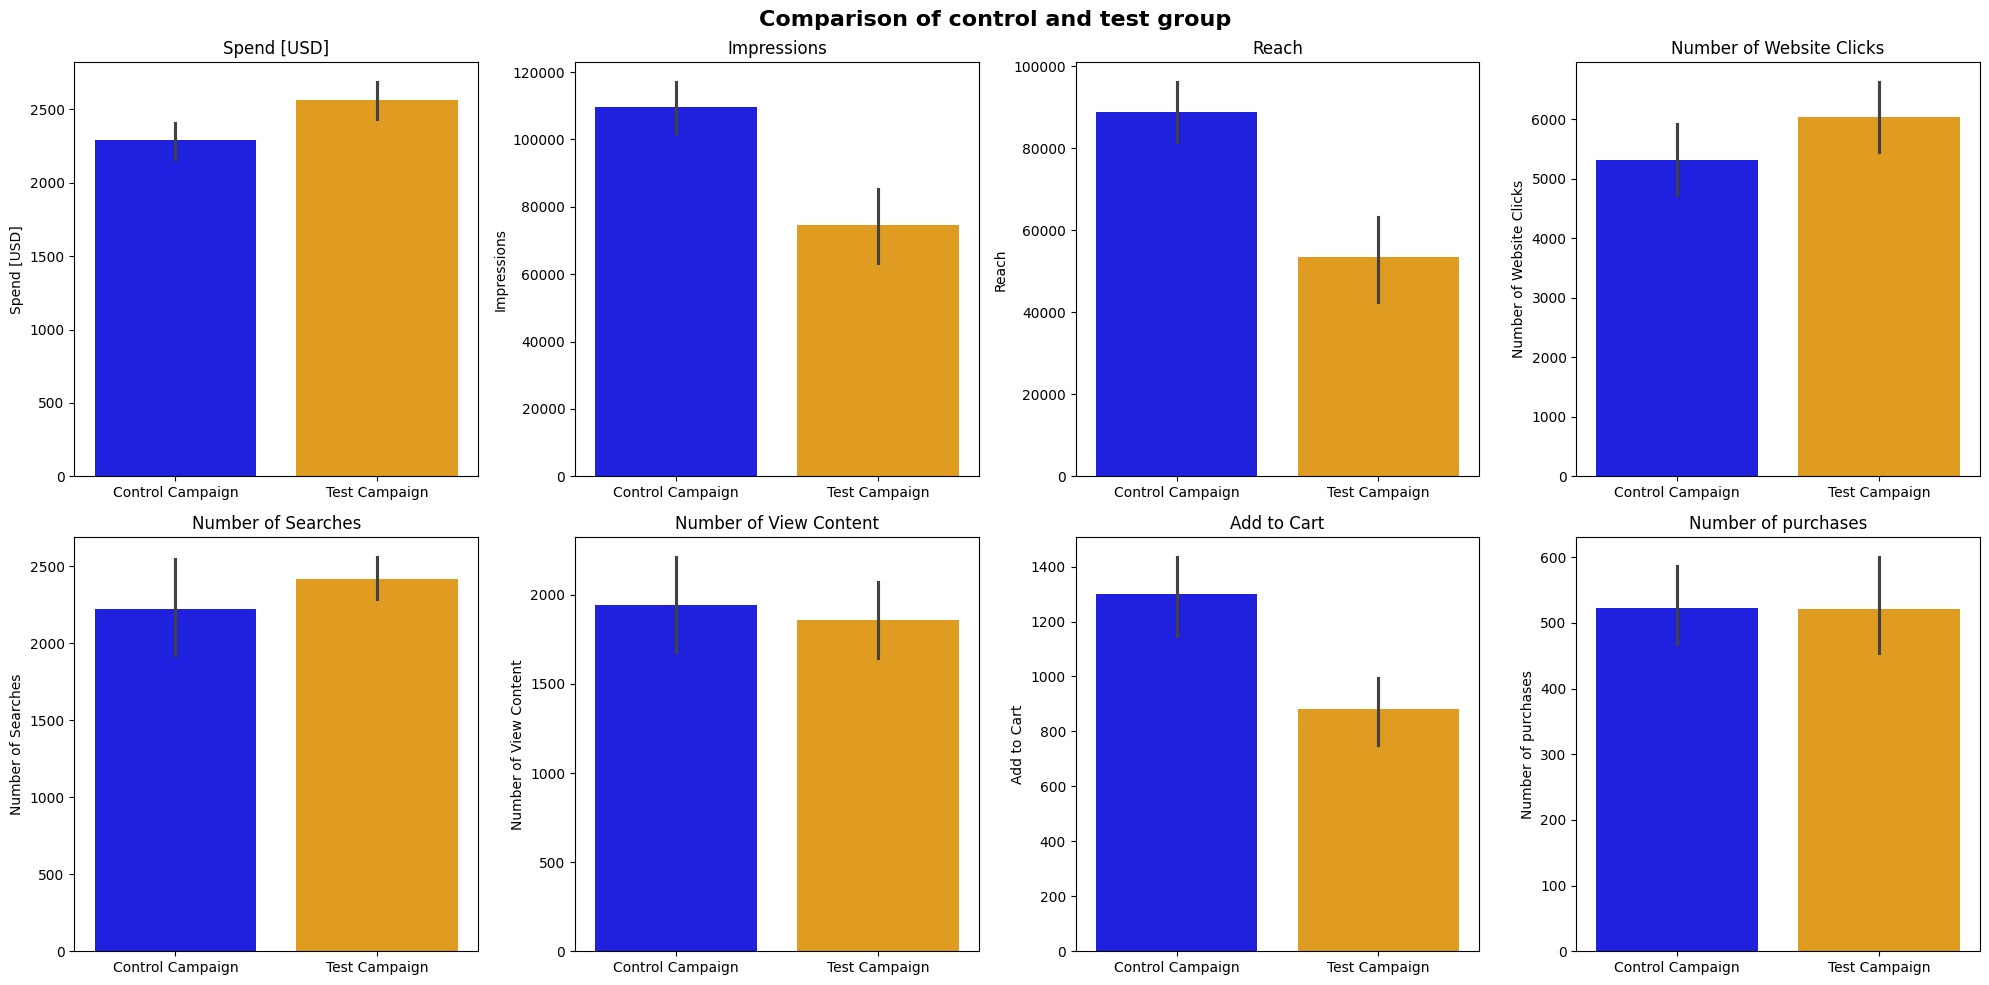

In [16]:
metrics = ["Spend [USD]", "Impressions", "Reach",
"Number of Website Clicks", "Number of Searches",
"Number of View Content", "Add to Cart", "Number of purchases"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Comparison of control and test group", fontsize=16, fontweight='bold')

for i, metric in enumerate(metrics):
    row, col = divmod(i, 4)
    sns.barplot(data=concat_table, x="Campaign Name", y=metric, ax=axes[row, col], palette=["blue", "orange"])
    axes[row, col].set_title(metric)
    axes[row, col].set_xlabel("")

plt.tight_layout()

### Let's calculate the necessary metrics for the analysis.

In [19]:
concat_table["Click-Through Rate"] = concat_table["Number of Website Clicks"] / concat_table["Impressions"]
concat_table["View Content Rate"] = concat_table["Number of View Content"] / concat_table["Impressions"]
concat_table["Conversion Rate"] = concat_table["Number of purchases"] / concat_table["Impressions"]
concat_table["Cost per Impression"] = concat_table["Spend [USD]"] / concat_table["Impressions"]
concat_table["Cost per Purchase"] = concat_table["Spend [USD]"] / concat_table["Number of purchases"]


In [20]:
concat_table.pivot_table(index="Campaign Name", values=["Click-Through Rate", "View Content Rate", "Conversion Rate", "Cost per Impression", "Cost per Purchase"], aggfunc="mean")

,Click-Through Rate,Conversion Rate,Cost per Impression,Cost per Purchase,View Content Rate
Campaign Name,,,,,
Control Campaign,0.050879,0.004993,0.021550,5.000927,0.018769
Test Campaign,0.102423,0.008425,0.042681,5.899589,0.031505


The test results show that the test group demonstrates a significant improvement in key metrics such as click-through rate, conversion rate, and content view rate, indicating higher effectiveness of the new marketing campaign. However, it is important to note that the cost per impression and cost per purchase were higher, which requires further analysis in terms of campaign expenses. Overall, the new approach (Test Campaign) is promising in terms of effectiveness, but to optimize the budget, it is crucial to focus on controlling costs to achieve the best price-quality ratio.

### Are the metric variables normally distributed or not?

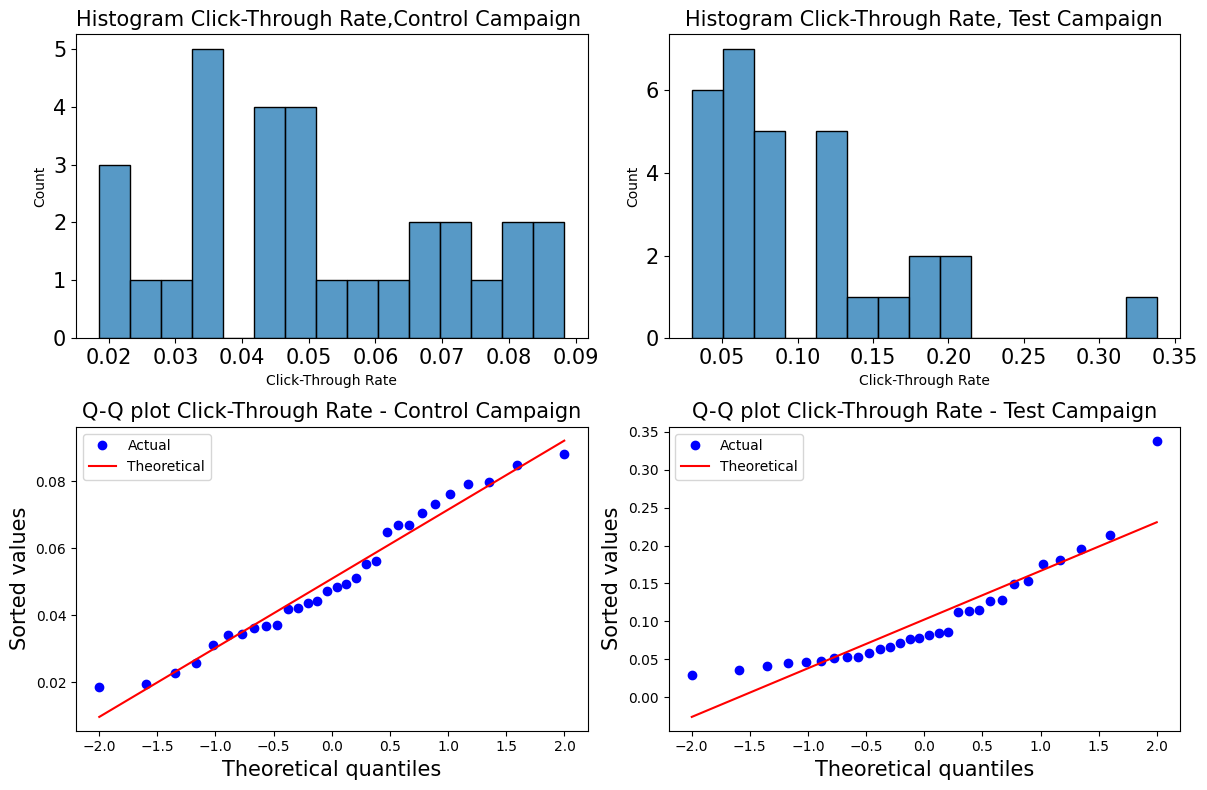

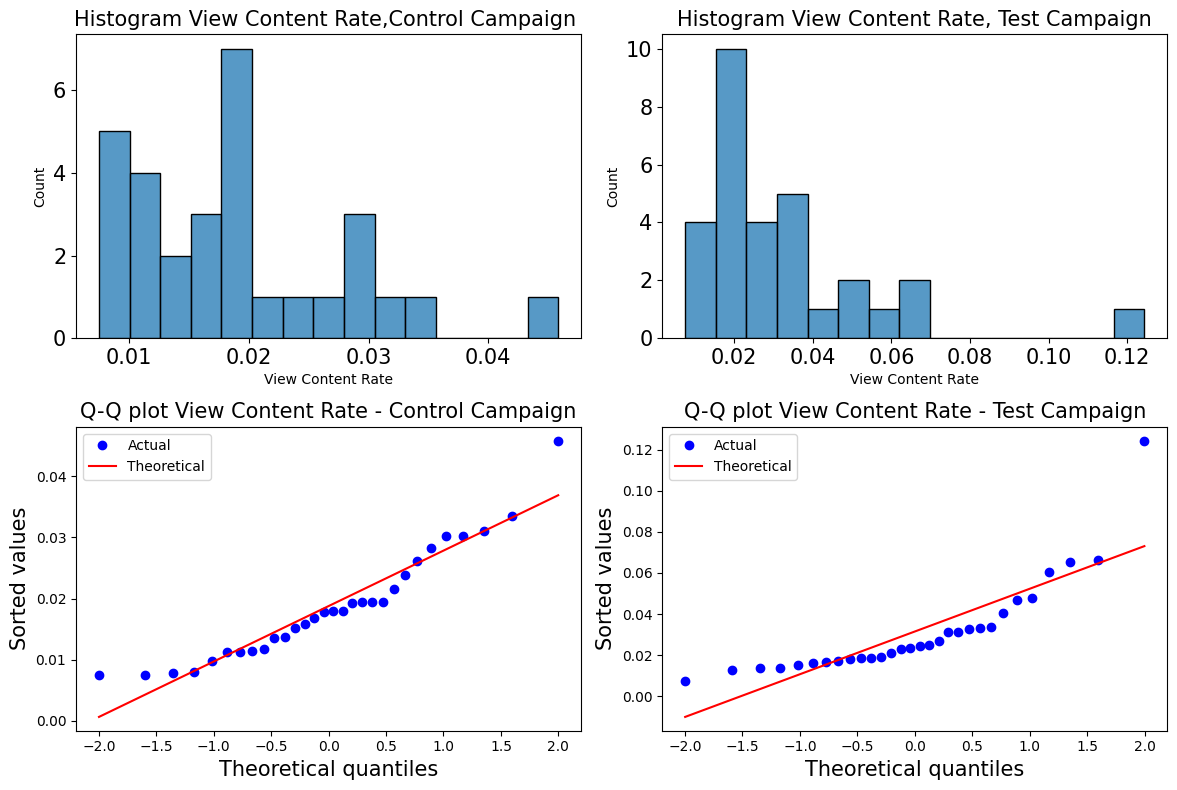

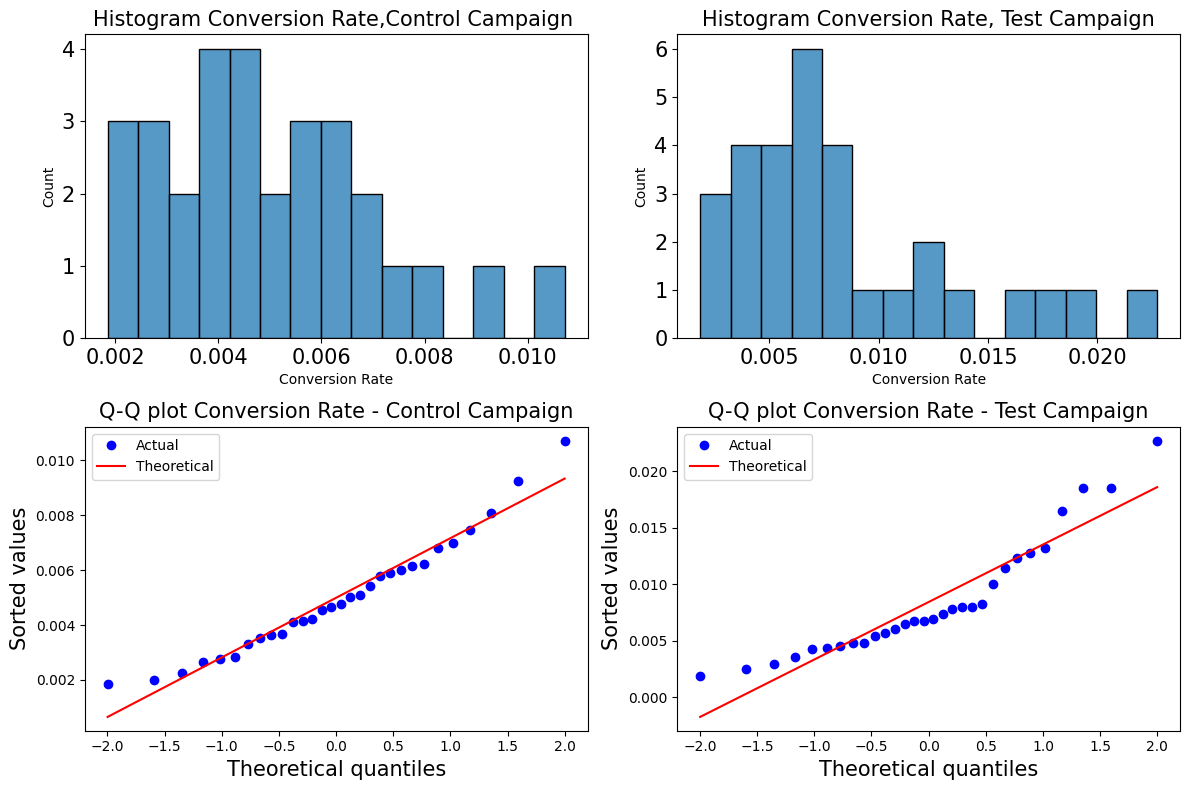

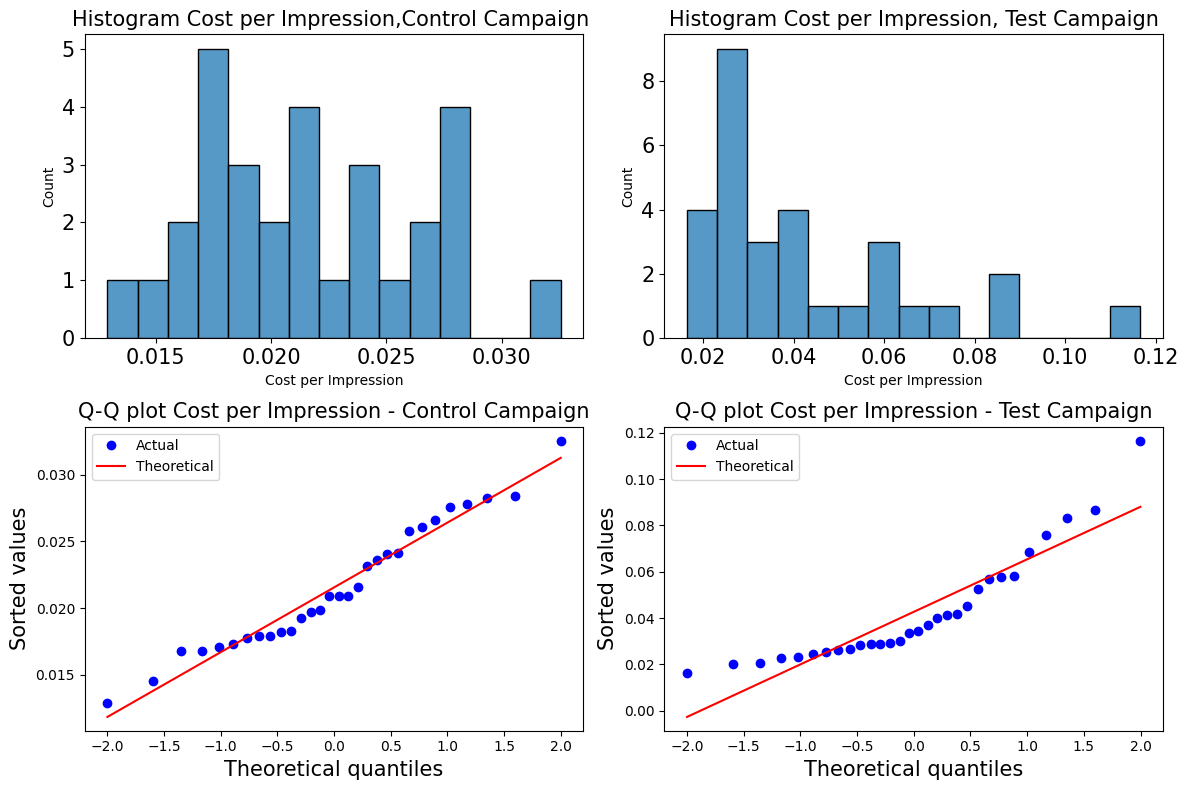

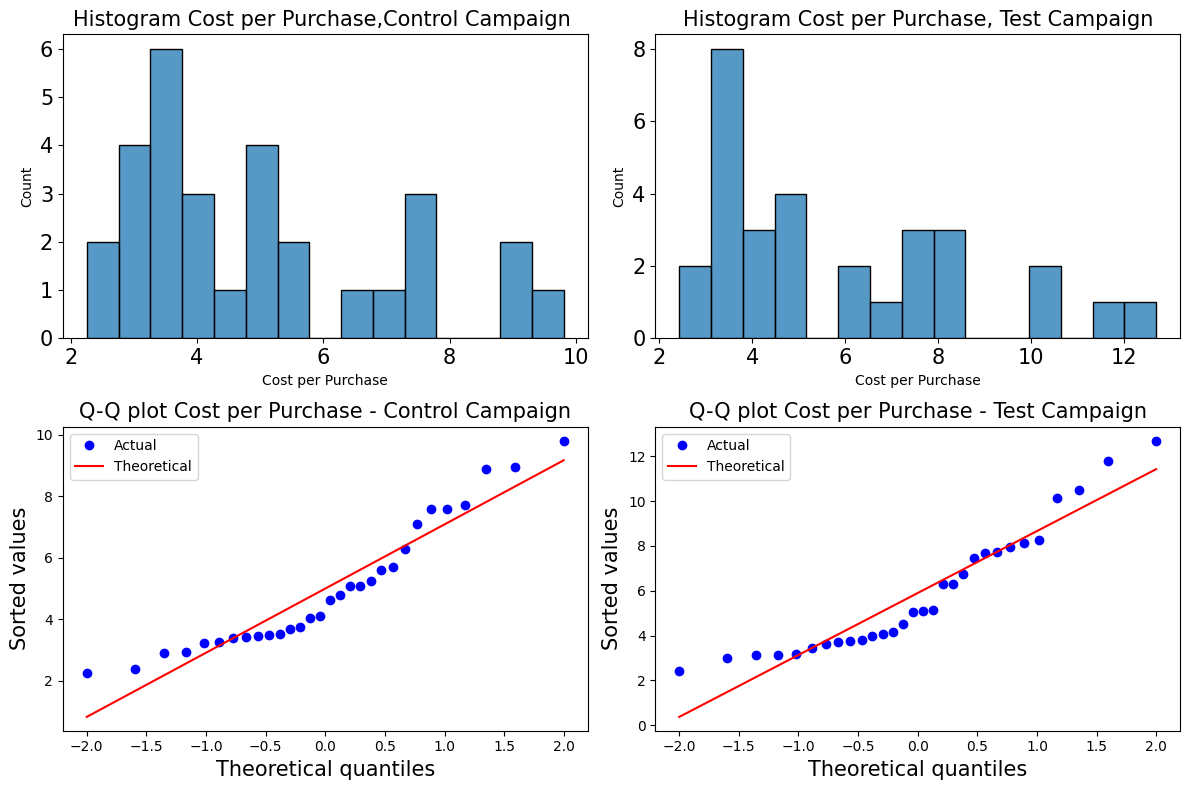

In [22]:
metrics = ["Click-Through Rate", "View Content Rate", "Conversion Rate", "Cost per Impression", "Cost per Purchase"]

for metric in metrics:

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    sns.histplot(concat_table[concat_table['Campaign Name'] == 'Control Campaign'][metric], bins=15, ax=axes[0, 0])
    axes[0, 0].xaxis.set_tick_params(labelsize=15)
    axes[0, 0].yaxis.set_tick_params(labelsize=15)
    axes[0, 0].set_title(f"Histogram {metric},Control Campaign ", fontsize=15)

    sns.histplot(concat_table[concat_table['Campaign Name'] == 'Test Campaign'][metric], bins=15, ax=axes[0, 1])
    axes[0, 1].xaxis.set_tick_params(labelsize=15)
    axes[0, 1].yaxis.set_tick_params(labelsize=15)
    axes[0, 1].set_title(f"Histogram {metric}, Test Campaign", fontsize=15)

    stats.probplot(concat_table[concat_table['Campaign Name'] == 'Control Campaign'][metric], dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title(f"Q-Q plot {metric} - Control Campaign", fontsize=15)
    axes[1, 0].set_xlabel("Theoretical quantiles", fontsize=15)
    axes[1, 0].set_ylabel("Sorted values", fontsize=15)
    axes[1, 0].legend(['Actual', 'Theoretical'])

    stats.probplot(concat_table[concat_table['Campaign Name'] == 'Test Campaign'][metric], dist="norm", plot=axes[1, 1])
    axes[1, 1].set_title(f"Q-Q plot {metric} - Test Campaign", fontsize=15)
    axes[1, 1].set_xlabel("Theoretical quantiles", fontsize=15)
    axes[1, 1].set_ylabel("Sorted values", fontsize=15)
    axes[1, 1].legend(['Actual', 'Theoretical'])

    plt.tight_layout()


Based on the analysis of the graphs, we can conclude that the metrics do not follow normal distributions. In the histogram, which should have a bell-shaped curve, we observe the absence of this shape. Additionally, in the Q-Q plot, the points do not align with the red line, which indicates a lack of normality. Some of the distributions appear skewed, which can likely be explained by the limited amount of data in the campaign.

### Testing

**The Shapiro-Wilk test** is a statistical test used to check the normality of a data distribution. It helps determine whether a sample can be considered to come from a normally distributed population.

In [23]:
for metric in metrics:

    print(f'\n{metric}:')

    test_stat, pvalue = shapiro(concat_table[concat_table['Campaign Name'] == 'Control Campaign'][metric])
    print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))

    test_stat, pvalue = shapiro(concat_table[concat_table['Campaign Name'] == 'Test Campaign'][metric])
    print('Test Stat = %.4f, p-value = %.4f' % (test_stat, pvalue))


Click-Through Rate:
Test Stat = 0.9583, p-value = 0.2807
Test Stat = 0.8409, p-value = 0.0004

View Content Rate:
Test Stat = 0.9187, p-value = 0.0248
Test Stat = 0.7473, p-value = 0.0000

Conversion Rate:
Test Stat = 0.9578, p-value = 0.2723
Test Stat = 0.8838, p-value = 0.0035

Cost per Impression:
Test Stat = 0.9630, p-value = 0.3678
Test Stat = 0.8486, p-value = 0.0006

Cost per Purchase:
Test Stat = 0.9049, p-value = 0.0111
Test Stat = 0.8966, p-value = 0.0069


**Click-Through Rate**: For the **control group**: p-value = 0.2807, indicating **normality** of the distribution. For the **test group**: p-value = 0.0004, indicating **non-normality** of the distribution.

**View Content Rate**: For the **control group**: p-value = 0.0248, indicating non-normality. For the **test group**: p-value = 0.0000, also indicating **non-normality**.

**Conversion Rate**: For the **control group**: p-value = 0.2723, indicating **normality** of the distribution. For the **test group**: p-value = 0.0035, indicating **non-normality** of the distribution.

**Cost per Impression**: For the **control group**: p-value = 0.3678, indicating **normality** of the distribution. For the **test group**: p-value = 0.0006, indicating **non-normality**.

**Cost per Purchase**: For the **control group**: p-value = 0.0111, indicating **non-normality** of the distribution. For the **test group**: p-value = 0.0069, also indicating **non-normality** of the distribution.

**Conclusion**: For the control group, some metrics (Click-Through Rate, Conversion Rate, Cost per Impression) have p-value > 0.05, indicating normality of the distribution. However, for the test group, all these metrics have p-value < 0.05, meaning their distributions are not normal.

Considering that the sample size is small and the distributions I am examining are skewed, the t-test may not be reliable. This is because the central limit theorem (which can justify the use of the t-test for skewed variables) requires a larger sample size.

Hypothesis Testing

Null Hypothesis (H0): There is **no significant difference** in performance between the control group and the test group.

Alternative Hypothesis (H1): There is a **significant difference** in performance between the control group and the test group.

In [25]:
for metric in metrics:

    print(f'\n{metric}:')
    t_stat, p_value = stats.ttest_ind(concat_table[concat_table['Campaign Name'] == 'Control Campaign'][metric], concat_table[concat_table['Campaign Name'] == 'Test Campaign'][metric])
    print(f"T-statistic: {t_stat}, P-value: {p_value}")


Click-Through Rate:
T-statistic: -3.9962501835865276, P-value: 0.00018398526312426124

View Content Rate:
T-statistic: -2.7743737957457926, P-value: 0.007429253084171041

Conversion Rate:
T-statistic: -3.336143277653973, P-value: 0.0014863795787692907

Cost per Impression:
T-statistic: -4.778365736857713, P-value: 1.2457700607921947e-05

Cost per Purchase:
T-statistic: -1.406289257896576, P-value: 0.16497351064327181


For Click-Through Rate, View Content Rate, Conversion Rate, and Cost per Impression, the differences between the groups are statistically significant (p-value < 0.05), indicating the impact of the test campaign on these metrics. For Cost per Purchase, p-value > 0.05, meaning there are no significant changes between the control and test groups for this metric. All t-statistics are negative, indicating that the mean value of the test group is lower than the mean of the control group for all metrics.

# Overall conclusion:

During the analysis, we observed statistically **significant differences** in the **click-through rate, content view rate, conversion rate, and cost per impression between the control and test groups**. This indicates an improvement in the results of the test campaign compared to the control metrics. However, **for cost per purchase, no statistically significant difference** was found, meaning the new approach (test campaign) did not have a significant impact on this parameter.

These observations lead to the conclusion that the **new campaign** (Test Campaign) **positively influenced most of the metrics**, **except for the cost per purchase**. All these results were recorded throughout the analysis, allowing for well-founded conclusions about the campaign's effectiveness.


### Recommendations

Based on the conducted analysis and statistical results, I have the following recommendations:

1. **Optimization of Marketing Strategy**: Since the click-through rate (CTR),
content view rate, and conversion rate showed significant improvement in the test group, this indicates that the new campaign (Test Campaign) is effective in engaging users and driving higher activity. It is recommended to continue the implementation of the test campaign to further increase effectiveness.
2. **Improving User Engagement**: Given the improvement in content view and conversion rates, there is a sense in further optimizing the campaign content to engage users even more and increase conversions. It might be worth refining the creatives and messages shown to users to achieve better results in product interaction.
3. **Advertising Cost Analysis**: The cost per impression in the test group was higher, which requires further analysis. Since the increased cost per impression may negatively impact campaign profitability, it is recommended to explore ways to optimize advertising costs while maintaining the balance between efficiency and expenses.
4. **Ongoing Monitoring of Purchase Price**: The test results did not show a statistically significant difference in the purchase price. This might indicate that the changes in the campaign did not have a substantial impact on this parameter. It is recommended to conduct additional analyses to identify potential factors that could influence the purchase price or focus on other aspects of the advertising campaign to achieve the desired result in this area.
5. **Further Experiments and Testing**: For a deeper understanding of the impact of the new campaign on all key metrics, it is recommended to conduct additional A/B tests or analyses using other variables to precisely assess its effectiveness and find ways for further optimization.

Overall, the new campaign (Test Campaign) demonstrates positive results in a number of important metrics, indicating its effectiveness. However, attention should be given to optimizing costs and further refining the campaign to maximize results.
